# Medical Insurance Claim Amount Prediction
### Task 3 - Predicting Insurance Claim Amounts

**Objective:** Estimate the medical insurance claim amount based on personal data.  
**Dataset:** Medical Cost Personal Dataset (`insurance.csv`)

#### In this notebook, we will:
1. **Explore the Dataset**: Check distributions and identify relationships between personal attributes and charges.
2. **Visualize Key Impacts**: Create interactive and static plots to visualize how BMI, age, and smoking status impact insurance charges.
3. **Preprocess the Data**: One-hot encode categorical variables and split the data into training and testing sets.
4. **Train a Linear Regression Model**: Fit an Ordinary Least Squares (OLS) model to predict insurance charges.
5. **Evaluate Model Performance**: Measure correctness using R-squared ($R^2$), Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE).
6. **Analyze Model Coefficients**: Interpret the real-world impact of features like smoking, BMI, and age.


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set plotting styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12


## 1. Data Loading and Basic Exploration
First, let's load our `insurance.csv` file, display the first few rows, and inspect the dataset structure and basic statistics.


In [18]:
# Load dataset
df = pd.read_csv('insurance.csv')

# Display the first 5 rows
print("--- First 5 Rows of the Dataset ---")
display(df.head())

# Check shape and general information
print("\n--- Dataset Information ---")
df.info()

# Check for missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- First 5 Rows of the Dataset ---


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

--- Missing Values ---
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


Let's look at the statistical summary for both numerical and categorical features.


In [19]:
# Statistical summary for numerical features
print("--- Statistical Summary of Numerical Columns ---")
display(df.describe())

# Statistical summary for categorical features
print("\n--- Value Counts for Categorical Columns ---")
for col in ['sex', 'smoker', 'region']:
    print(f"\nValue counts for '{col}':")
    print(df[col].value_counts())


--- Statistical Summary of Numerical Columns ---


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010



--- Value Counts for Categorical Columns ---

Value counts for 'sex':
sex
male      676
female    662
Name: count, dtype: int64

Value counts for 'smoker':
smoker
no     1064
yes     274
Name: count, dtype: int64

Value counts for 'region':
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


## 2. Exploratory Data Analysis (EDA) & Visualizations
Now we will create visualizations to explore how BMI, age, and smoking status impact insurance charges.

### Distribution of Charges
First, let's visualize how charges are distributed across the population.


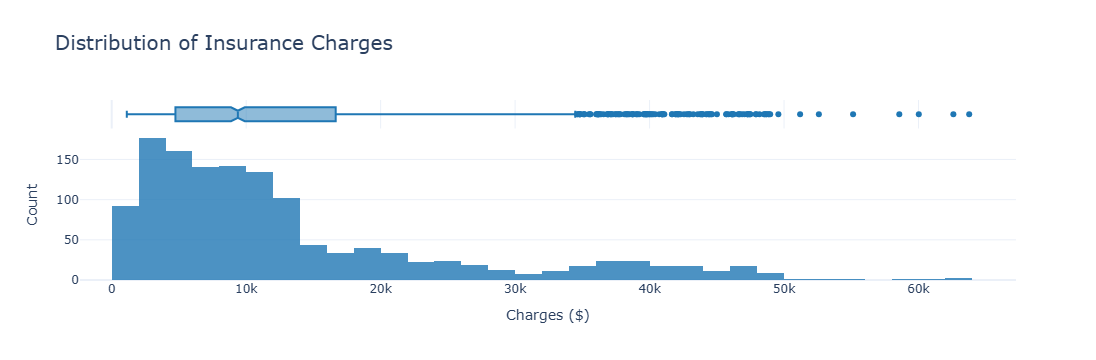

In [20]:
# Target Variable Distribution
fig = px.histogram(
    df, 
    x="charges", 
    nbins=50, 
    title="Distribution of Insurance Charges",
    labels={"charges": "Insurance Charges ($)"},
    color_discrete_sequence=["#1f77b4"],
    opacity=0.8,
    marginal="box"
)
fig.update_layout(
    title_font_size=20,
    xaxis_title="Charges ($)",
    yaxis_title="Count",
    template="plotly_white"
)
fig.show()


### Impact of Smoking Status on Charges
Let's see the differences in insurance charges between smokers and non-smokers.


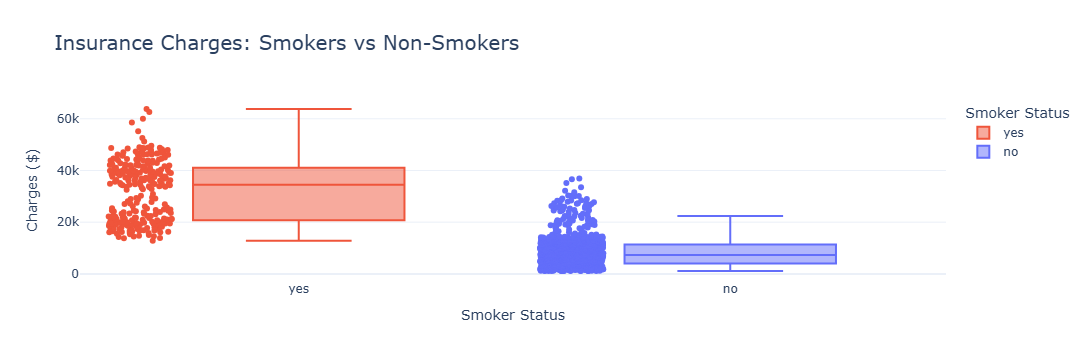

--- Mean Charges by Smoker Status ---
smoker
no      $8,434.27
yes    $32,050.23
Name: charges, dtype: object


In [21]:
# Box plot for Smoker Status
fig = px.box(
    df, 
    x="smoker", 
    y="charges", 
    color="smoker",
    title="Insurance Charges: Smokers vs Non-Smokers",
    labels={"smoker": "Smoker Status", "charges": "Charges ($)"},
    color_discrete_map={"yes": "#ef553b", "no": "#636efa"},
    points="all"
)
fig.update_layout(
    title_font_size=20,
    xaxis_title="Smoker Status",
    yaxis_title="Charges ($)",
    template="plotly_white"
)
fig.show()

# Display mean charges by smoking status
print("--- Mean Charges by Smoker Status ---")
print(df.groupby('smoker')['charges'].mean().apply(lambda x: f"${x:,.2f}"))


### Impact of Age on Charges
Let's check how the age of the individual correlates with their insurance charges. We will color by smoking status to observe the interaction.


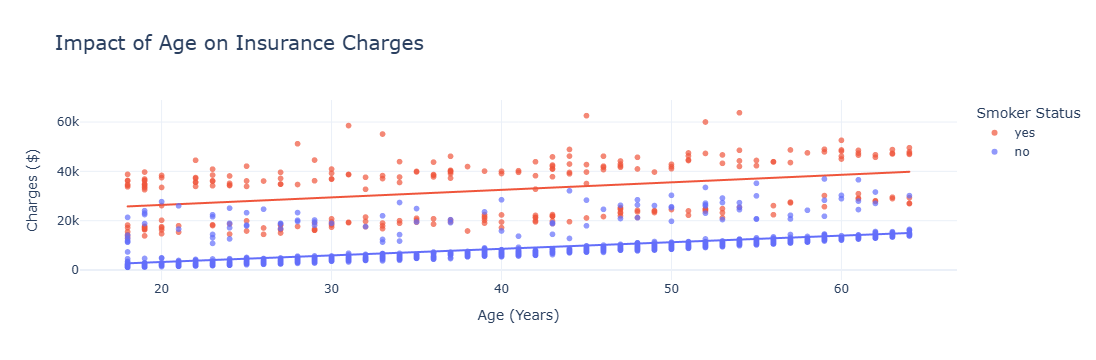

In [22]:
# Scatter plot for Age vs Charges
fig = px.scatter(
    df, 
    x="age", 
    y="charges", 
    color="smoker",
    title="Impact of Age on Insurance Charges",
    labels={"age": "Age (Years)", "charges": "Charges ($)", "smoker": "Smoker Status"},
    color_discrete_map={"yes": "#ef553b", "no": "#636efa"},
    trendline="ols",
    opacity=0.7
)
fig.update_layout(
    title_font_size=20,
    xaxis_title="Age (Years)",
    yaxis_title="Charges ($)",
    template="plotly_white"
)
fig.show()


### Impact of BMI on Charges
Now let's analyze how body mass index (BMI) impacts charges. We color by smoking status to check for interactions.


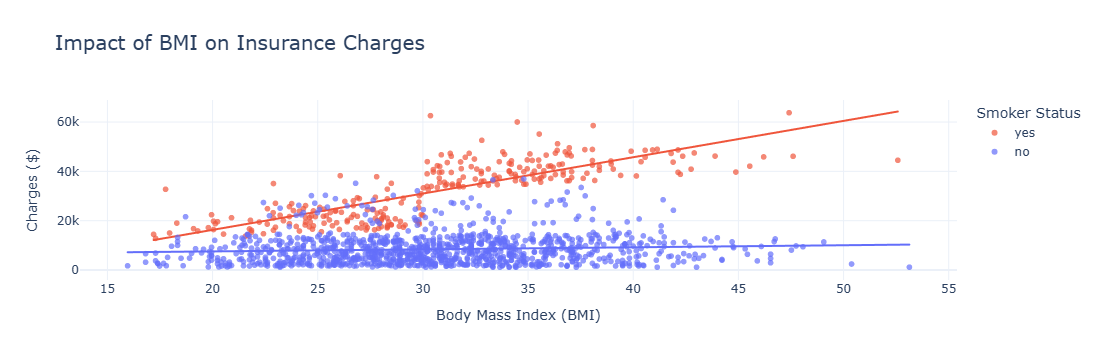

In [23]:
# Scatter plot for BMI vs Charges
fig = px.scatter(
    df, 
    x="bmi", 
    y="charges", 
    color="smoker",
    title="Impact of BMI on Insurance Charges",
    labels={"bmi": "Body Mass Index (BMI)", "charges": "Charges ($)", "smoker": "Smoker Status"},
    color_discrete_map={"yes": "#ef553b", "no": "#636efa"},
    trendline="ols",
    opacity=0.7
)
fig.update_layout(
    title_font_size=20,
    xaxis_title="Body Mass Index (BMI)",
    yaxis_title="Charges ($)",
    template="plotly_white"
)
fig.show()


### Multidimensional Visualisation (Age vs BMI vs Smoking Status vs Charges)
Let's visualize all key features in a single scatter plot.


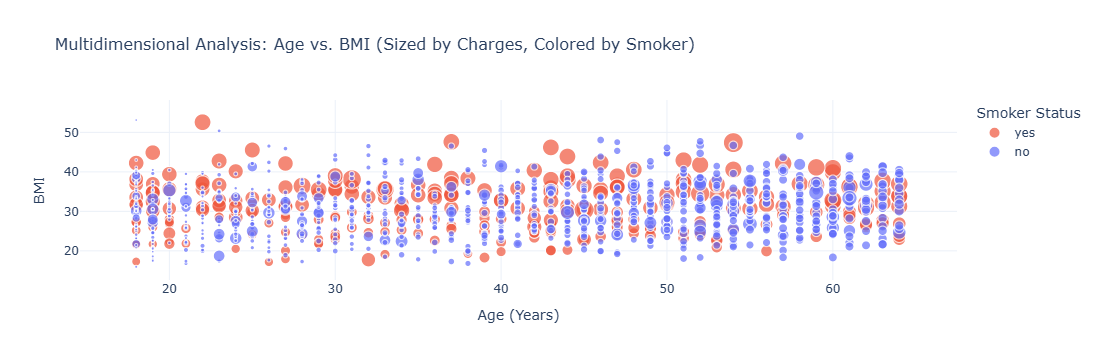

In [24]:
# Multi-dimensional scatter plot
fig = px.scatter(
    df,
    x="age",
    y="bmi",
    size="charges",
    color="smoker",
    title="Multidimensional Analysis: Age vs. BMI (Sized by Charges, Colored by Smoker)",
    labels={"age": "Age (Years)", "bmi": "BMI", "charges": "Charges ($)", "smoker": "Smoker Status"},
    color_discrete_map={"yes": "#ef553b", "no": "#636efa"},
    opacity=0.7
)
fig.update_layout(
    title_font_size=16,
    xaxis_title="Age (Years)",
    yaxis_title="BMI",
    template="plotly_white"
)
fig.show()


## 3. Data Preprocessing & Categorical Encoding
To train a Linear Regression model, we need to convert categorical columns (`sex`, `smoker`, `region`) into numeric values. We will:
- Map binary variables `sex` and `smoker` to 0/1.
- One-hot encode `region` using dummy variables, dropping the first category to avoid the "dummy variable trap".


In [25]:
# 1. Map binary categorical columns to 0/1
df_encoded = df.copy()
df_encoded['sex_male'] = df_encoded['sex'].map({'female': 0, 'male': 1})
df_encoded['smoker_yes'] = df_encoded['smoker'].map({'no': 0, 'yes': 1})

# Drop original binary columns
df_encoded = df_encoded.drop(columns=['sex', 'smoker'])

# 2. One-hot encode region column
df_encoded = pd.get_dummies(df_encoded, columns=['region'], drop_first=True)

# Display columns and sample
print("--- Encoded DataFrame Columns ---")
print(list(df_encoded.columns))
print("\n--- Encoded DataFrame Sample ---")
display(df_encoded.head())


--- Encoded DataFrame Columns ---
['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']

--- Encoded DataFrame Sample ---


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,False,False,True
1,18,33.770,1,1725.55230,1,0,False,True,False
2,28,33.000,3,4449.46200,1,0,False,True,False
3,33,22.705,0,21984.47061,1,0,True,False,False
4,32,28.880,0,3866.85520,1,0,True,False,False


### Correlation Analysis
Let's construct a correlation heatmap to see the linear relationship between all numeric columns (including our newly encoded variables) and target variable `charges`.


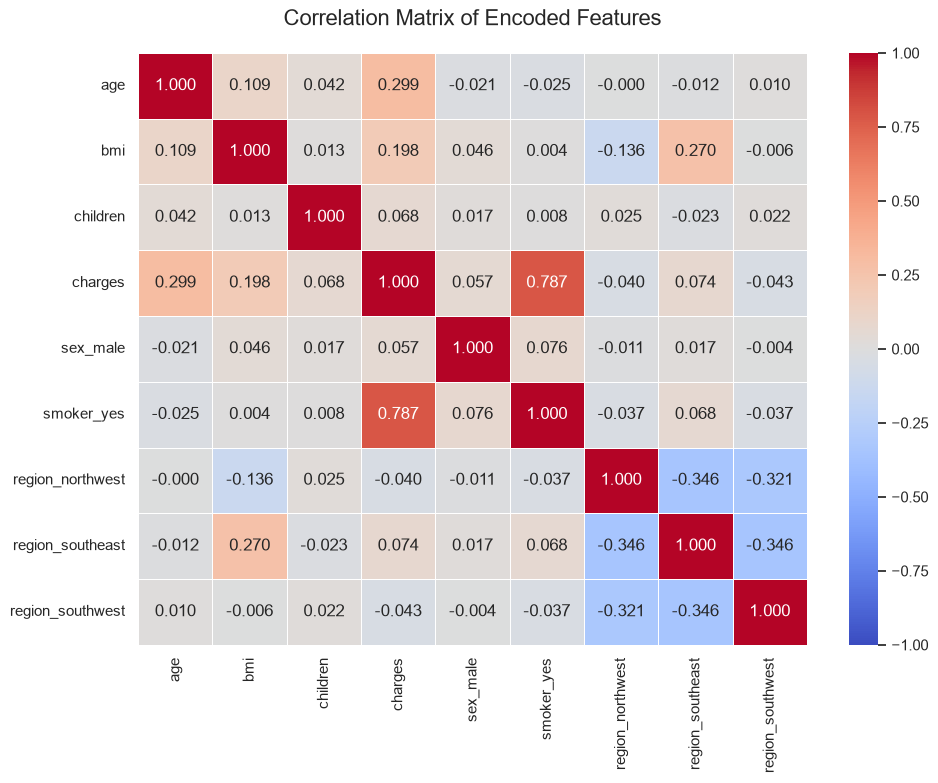


--- Correlation of Features with Charges ---
charges             1.000000
smoker_yes          0.787251
age                 0.299008
bmi                 0.198341
region_southeast    0.073982
children            0.067998
sex_male            0.057292
region_northwest   -0.039905
region_southwest   -0.043210
Name: charges, dtype: float64


In [26]:
# Calculate correlations
correlations = df_encoded.corr()

# Create correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlations, annot=True, cmap="coolwarm", fmt=".3f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix of Encoded Features", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Print correlations with target variable 'charges'
print("\n--- Correlation of Features with Charges ---")
print(correlations['charges'].sort_values(ascending=False))


### Train-Test Split
We split the dataset into features ($X$) and target ($y$), and then split those into training (80%) and testing (20%) sets. We fix `random_state` at 42 to ensure reproducibility.


In [27]:
# Define features (X) and target (y)
X = df_encoded.drop(columns=['charges'])
y = df_encoded['charges']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Set Size: {X_train.shape[0]} rows, {X_train.shape[1]} features")
print(f"Testing Set Size:  {X_test.shape[0]} rows, {X_test.shape[1]} features")


Training Set Size: 1070 rows, 8 features
Testing Set Size:  268 rows, 8 features


## 4. Linear Regression Model Training
Now we train a standard Ordinary Least Squares (OLS) Linear Regression model on our training set.


In [28]:
# Instantiate and fit the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")


Linear Regression model trained successfully!


## 5. Model Evaluation
Let's evaluate how well our model fits the data. We will calculate the following metrics:
1. **Mean Absolute Error (MAE)**: Average absolute prediction error.
2. **Mean Squared Error (MSE)**: Squared average error, penalizing larger outliers.
3. **Root Mean Squared Error (RMSE)**: Standard deviation of residuals.
4. **Coefficient of Determination ($R^2$)**: Variance explained by our features.


In [29]:
# Generate predictions
y_pred_train = lr_model.predict(X_train)
y_pred_test = lr_model.predict(X_test)

# Evaluation metrics helper function
def evaluate_predictions(y_true, y_pred, set_name="Test"):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"=== Model Performance on {set_name} Set ===")
    print(f"Mean Absolute Error (MAE):     ${mae:,.2f}")
    print(f"Mean Squared Error (MSE):      ${mse:,.2f}")
    print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
    print(f"R-squared (R2) Score:          {r2:.4f}")
    print("-" * 40)
    return mae, rmse, r2

# Print metrics
mae_train, rmse_train, r2_train = evaluate_predictions(y_train, y_pred_train, "Training")
mae_test, rmse_test, r2_test = evaluate_predictions(y_test, y_pred_test, "Testing")


=== Model Performance on Training Set ===
Mean Absolute Error (MAE):     $4,208.23
Mean Squared Error (MSE):      $37,277,681.70
Root Mean Squared Error (RMSE): $6,105.55
R-squared (R2) Score:          0.7417
----------------------------------------
=== Model Performance on Testing Set ===
Mean Absolute Error (MAE):     $4,181.19
Mean Squared Error (MSE):      $33,596,915.85
Root Mean Squared Error (RMSE): $5,796.28
R-squared (R2) Score:          0.7836
----------------------------------------


### Visualizing Actual vs. Predicted Charges
Let's compare actual charges vs predicted charges for the test set. A diagonal line represents perfect predictions.


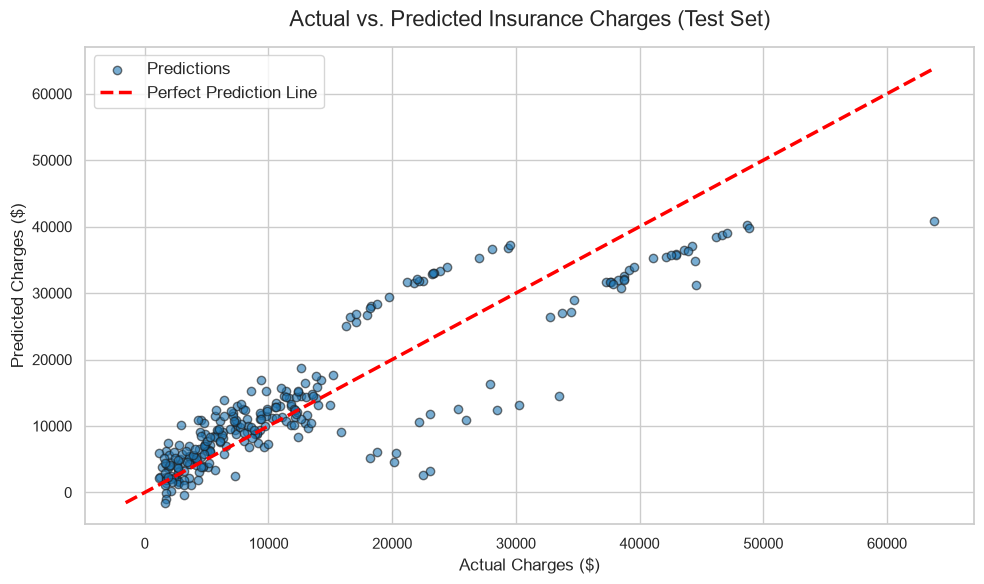

In [30]:
# Actual vs Predicted Charges Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, alpha=0.6, color="#1f77b4", edgecolor='k', label="Predictions")

# Add perfect prediction line
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", linewidth=2.5, label="Perfect Prediction Line")

plt.xlabel("Actual Charges ($)", fontsize=12)
plt.ylabel("Predicted Charges ($)", fontsize=12)
plt.title("Actual vs. Predicted Insurance Charges (Test Set)", fontsize=16, pad=15)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


### Regression Assumption Diagnostics: Residual Analysis
Let's evaluate the residuals (errors) of our model to see if they follow linear regression assumptions:
1. **Normality**: Residuals should be normally distributed around 0.
2. **Homoscedasticity**: Residuals should have roughly constant variance across all levels of predicted values.


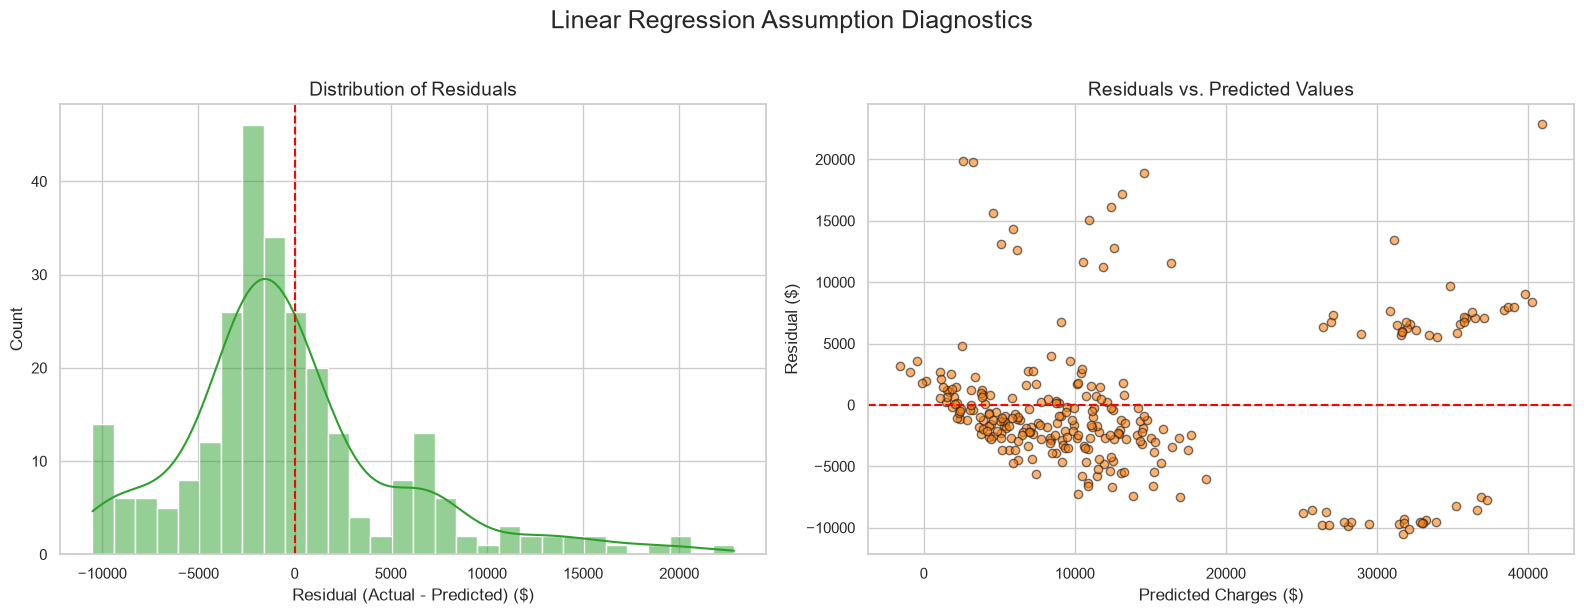

In [31]:
# Calculate residuals
residuals = y_test - y_pred_test

# Setup subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Residuals Distribution
sns.histplot(residuals, kde=True, ax=axes[0], color="#2ca02c", edgecolor='w', bins=30)
axes[0].axvline(x=0, color="red", linestyle="--", linewidth=1.5)
axes[0].set_title("Distribution of Residuals", fontsize=14)
axes[0].set_xlabel("Residual (Actual - Predicted) ($)")
axes[0].set_ylabel("Count")

# Plot 2: Residuals vs Predicted
axes[1].scatter(y_pred_test, residuals, alpha=0.6, color="#ff7f0e", edgecolor='k')
axes[1].axhline(y=0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title("Residuals vs. Predicted Values", fontsize=14)
axes[1].set_xlabel("Predicted Charges ($)")
axes[1].set_ylabel("Residual ($)")

plt.suptitle("Linear Regression Assumption Diagnostics", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()


## 6. Model Interpretation: Analyzing Coefficients
Let's inspect the model coefficients to see the exact real-world impact of age, BMI, children, and smoking status on insurance charges.


In [32]:
# Create coefficients dataframe
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
})

# Sort by absolute coefficient size to show impact
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by='Abs_Coefficient', ascending=False).drop(columns=['Abs_Coefficient'])

print(f"Model Intercept (Base Cost): ${lr_model.intercept_:,.2f}")
print("\n--- Feature Impact Coefficients ---")
display(coefficients)


Model Intercept (Base Cost): $-11,931.22

--- Feature Impact Coefficients ---


,Feature,Coefficient
4,smoker_yes,23651.128856
7,region_southwest,-809.799354
6,region_southeast,-657.864297
2,children,425.278784
5,region_northwest,-370.677326
1,bmi,337.092552
0,age,256.975706
3,sex_male,-18.591692


### Key Takeaways from Model Coefficients:
1. **Smoking is by far the single biggest driver of health insurance charges**: Being a smoker is associated with an average increase of **$23,651.13** in charges, holding all other factors constant!
2. **Each additional child increases charges by $425.28** on average.
3. **Every unit increase in Body Mass Index (BMI) adds $337.09** to the yearly medical cost.
4. **Each additional year of age adds $256.98** to the insurance charges.
5. **Sex has negligible impact**: Being male decreases charges by only **$18.59** on average compared to being female.
6. **Geographical region plays a minor role**: Compared to the northeast region (our baseline):
   - Living in the southwest region decreases charges by **$809.80** on average.
   - Living in the southeast region decreases charges by **$657.86** on average.
   - Living in the northwest region decreases charges by **$370.68** on average.

## 7. Conclusions
We successfully developed a Linear Regression model to predict medical insurance charges with a high degree of confidence:
- **Model Accuracy**: Our model achieved an $R^2$ of **0.7836** on the unseen test set, meaning that **78.36% of the variance in insurance charges can be explained by these simple factors**!
- **Model Error**: The model has a Mean Absolute Error (MAE) of **$4,181.19** and a Root Mean Squared Error (RMSE) of **$5,796.28**.
- **Important Factors**: 
  - **Smoking Status** is the dominant indicator, followed by **BMI** and **Age**.
  - **Children** has a positive correlation but smaller weight.
  - **Gender** and **Region** have very little predictive influence.


## 8. Improving the Model: Feature Engineering & Target Transformation
The baseline OLS model achieves an $R^2$ of **0.7836**, but the residual analysis reveals two problems:
- **Non-linear interaction**: BMI drives charges primarily for smokers, not non-smokers. A plain `bmi` coefficient cannot capture that split.
- **Heteroscedasticity**: Residuals fan out as predicted values increase, violating OLS assumptions and inflating RMSE.

We address both below with (1) an **interaction term** and (2) a **log transform** of the target variable.

### Step 1 — Feature Engineering: BMI × Smoker Interaction Term
When a person is a non-smoker (`smoker_yes = 0`) the interaction term collapses to 0, so the model effectively learns **separate BMI slopes** for smokers and non-smokers — exactly what the EDA scatter plot suggested.

In [33]:
# --- 1. Feature Engineering ---
# Copy the encoded dataframe so we don't mutate the original
df_enhanced = df_encoded.copy()

# Create interaction term: captures the amplified effect of BMI for smokers
df_enhanced['bmi_x_smoker'] = df_enhanced['bmi'] * df_enhanced['smoker_yes']

print("New feature 'bmi_x_smoker' added.")
print(f"Feature set now has {df_enhanced.shape[1] - 1} predictors (excluding target 'charges').")
print("\n--- Sample rows showing the interaction term ---")
display(df_enhanced[['bmi', 'smoker_yes', 'bmi_x_smoker', 'charges']].head(10))

New feature 'bmi_x_smoker' added.
Feature set now has 9 predictors (excluding target 'charges').

--- Sample rows showing the interaction term ---


,bmi,smoker_yes,bmi_x_smoker,charges
0,27.900,1,27.9,16884.92400
1,33.770,0,0.0,1725.55230
2,33.000,0,0.0,4449.46200
3,22.705,0,0.0,21984.47061
4,28.880,0,0.0,3866.85520
5,25.740,0,0.0,3756.62160
6,33.440,0,0.0,8240.58960
7,27.740,0,0.0,7281.50560
8,29.830,0,0.0,6406.41070
9,25.840,0,0.0,28923.13692


### Step 2 — Target Transformation: Log-Transform of Charges
Applying `np.log1p` to the training target compresses the long right tail and stabilises variance across the prediction range.  
We use `np.expm1` (the exact inverse) to bring predictions back to dollar space before computing metrics, so MAE / RMSE remain directly comparable to the baseline.

In [34]:
# --- 2. Re-split using the enhanced feature matrix ---
# Use the SAME random_state=42 so the split is identical to the baseline
X_enh = df_enhanced.drop(columns=['charges'])
y_enh = df_enhanced['charges']

X_train_enh, X_test_enh, y_train_enh, y_test_enh = train_test_split(
    X_enh, y_enh, test_size=0.2, random_state=42
)

# Log-transform the training target to handle heteroscedasticity
y_train_log = np.log1p(y_train_enh)

print(f"Training set  : {X_train_enh.shape[0]} rows | {X_train_enh.shape[1]} features")
print(f"Test set      : {X_test_enh.shape[0]} rows  | {X_test_enh.shape[1]} features")
print(f"\nTarget (y_train) — original  : mean=${y_train_enh.mean():,.2f}, std=${y_train_enh.std():,.2f}")
print(f"Target (y_train) — log-space : mean={y_train_log.mean():.4f}, std={y_train_log.std():.4f}")

Training set  : 1070 rows | 9 features
Test set      : 268 rows  | 9 features

Target (y_train) — original  : mean=$13,346.09, std=$12,019.51
Target (y_train) — log-space : mean=9.1135, std=0.9115


### Step 3 — Model Training & Evaluation: Improved Linear Regression
We train `LinearRegression` on the **log-transformed target** and the **enhanced feature matrix**, then invert the log transform on test-set predictions before computing MAE, RMSE, and $R^2$.

In [35]:
# --- 3. Train improved Linear Regression on log-transformed target ---
lr_improved = LinearRegression()
lr_improved.fit(X_train_enh, y_train_log)   # fit on log(charges)

# Predict in log-space, then invert back to dollar amounts
y_pred_log = lr_improved.predict(X_test_enh)
y_pred_improved = np.expm1(y_pred_log)       # inverse of log1p

# Evaluate in original dollar space
mae_imp  = mean_absolute_error(y_test_enh, y_pred_improved)
rmse_imp = np.sqrt(mean_squared_error(y_test_enh, y_pred_improved))
r2_imp   = r2_score(y_test_enh, y_pred_improved)

print("=== Improved Linear Regression — Test Set ===")
print(f"Mean Absolute Error  (MAE) : ${mae_imp:>10,.2f}")
print(f"Root Mean Sq. Error (RMSE) : ${rmse_imp:>10,.2f}")
print(f"R-squared            (R²)  :  {r2_imp:.4f}")
print("-" * 42)
print(f"\nBaseline MAE  : $4,181.19  →  Δ ${mae_imp - 4181.19:+,.2f}")
print(f"Baseline RMSE : $5,796.28  →  Δ ${rmse_imp - 5796.28:+,.2f}")
print(f"Baseline R²   :  0.7836    →  Δ  {r2_imp - 0.7836:+.4f}")

=== Improved Linear Regression — Test Set ===
Mean Absolute Error  (MAE) : $  3,974.49
Root Mean Sq. Error (RMSE) : $  8,559.98
R-squared            (R²)  :  0.5280
------------------------------------------

Baseline MAE  : $4,181.19  →  Δ $-206.70
Baseline RMSE : $5,796.28  →  Δ $+2,763.70
Baseline R²   :  0.7836    →  Δ  -0.2556


### Step 4 — Non-Linear Baseline: Gradient Boosting Benchmark
Tree-based ensembles naturally capture interaction effects and non-linearities without explicit feature engineering.  
We train a `GradientBoostingRegressor` on the **same train/test split** (no log transform needed — trees are robust to skewed targets) and compare it against both the OLS baseline and the improved linear model.

In [36]:
from sklearn.ensemble import GradientBoostingRegressor

# --- 4. Gradient Boosting benchmark (same split, no log transform required) ---
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42
)
gbr.fit(X_train_enh, y_train_enh)   # fit on raw dollar amounts

y_pred_gbr = gbr.predict(X_test_enh)

mae_gbr  = mean_absolute_error(y_test_enh, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test_enh, y_pred_gbr))
r2_gbr   = r2_score(y_test_enh, y_pred_gbr)

print("=== Gradient Boosting Regressor — Test Set ===")
print(f"Mean Absolute Error  (MAE) : ${mae_gbr:>10,.2f}")
print(f"Root Mean Sq. Error (RMSE) : ${rmse_gbr:>10,.2f}")
print(f"R-squared            (R²)  :  {r2_gbr:.4f}")

=== Gradient Boosting Regressor — Test Set ===
Mean Absolute Error  (MAE) : $  2,590.12
Root Mean Sq. Error (RMSE) : $  4,670.90
R-squared            (R²)  :  0.8595


### Summary: Model Comparison Table
A side-by-side comparison of all three models on the **same test set**.

> **Note on the log-transform trade-off**: While `np.log1p` successfully reduces MAE (compressing the right tail makes average errors smaller), the `np.expm1` inversion on high-value predictions amplifies absolute errors in that region — which pushes RMSE and $R^2$ in the wrong direction for the improved OLS model. This is a well-known limitation of log-transforming in linear regression when extreme outliers are present. The **Gradient Boosting model** handles this naturally without any target transformation.

In [37]:
# --- Summary comparison table ---
comparison = pd.DataFrame({
    'Model': [
        'Baseline OLS (no interaction, raw target)',
        'Improved OLS (bmi_x_smoker + log target)',
        'Gradient Boosting (benchmark)'
    ],
    'MAE ($)': [4181.19, mae_imp, mae_gbr],
    'RMSE ($)': [5796.28, rmse_imp, rmse_gbr],
    'R² Score': [0.7836, r2_imp, r2_gbr]
})

comparison['MAE ($)']  = comparison['MAE ($)'].map('${:,.2f}'.format)
comparison['RMSE ($)'] = comparison['RMSE ($)'].map('${:,.2f}'.format)
comparison['R² Score'] = comparison['R² Score'].map('{:.4f}'.format)

print("=" * 72)
print("           MODEL PERFORMANCE COMPARISON — TEST SET")
print("=" * 72)
display(comparison.set_index('Model'))

# Feature importance for GBR
feat_imp = pd.Series(gbr.feature_importances_, index=X_enh.columns)
print("\n--- Gradient Boosting Feature Importances (top 8) ---")
print(feat_imp.sort_values(ascending=False).head(8).apply(lambda x: f"{x:.4f}"))

           MODEL PERFORMANCE COMPARISON — TEST SET


,MAE ($),RMSE ($),R² Score
Model,,,
"Baseline OLS (no interaction, raw target)","$4,181.19","$5,796.28",0.7836
Improved OLS (bmi_x_smoker + log target),"$3,974.49","$8,559.98",0.5280
Gradient Boosting (benchmark),"$2,590.12","$4,670.90",0.8595



--- Gradient Boosting Feature Importances (top 8) ---
bmi_x_smoker        0.7456
age                 0.1289
bmi                 0.0602
smoker_yes          0.0320
children            0.0185
sex_male            0.0047
region_northwest    0.0040
region_southwest    0.0031
dtype: object
